# MATHFI model pipeline with quantitative biomarkers and visualization

In [1]:
# Add project root (the folder that contains "src/") to sys.path
import sys
import time
from pathlib import Path

def add_project_root(marker_dir="src", max_hops=5):
    p = Path.cwd().resolve()
    for _ in range(max_hops):
        if (p / marker_dir).exists():
            sys.path.insert(0, str(p))
            print(f"[OK] Added to sys.path: {p}")
            return
        p = p.parent
    raise RuntimeError(f"Could not find '{marker_dir}' within {max_hops} parents from {Path.cwd()}")

add_project_root()  

[OK] Added to sys.path: D:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation


In [2]:
# --- Imports ---
%matplotlib inline
import os, time, json, contextlib
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

# --- Your libs ---
from src.data.preprocessing import _iso_resize_and_pad
from apps.streamlit.lib.preprocess import preprocess_image_retina_from_pil  # <--- or your path where preprocess.py lives

# Vessel metrics
from src.retina_biomarkers import (
    to_bool_mask, skeletonize_mask, distance_transform, build_skeleton_graph,
    sample_width_along_skeleton, sample_widths_orthogonal,
    area_density, length_density, caliber_stats, tortuosity_stats, fractal_dimension_boxcount,
    junction_metrics, branching_and_bifurcation_angles, branching_angles_roi, gap_metrics, metrics_by_rings,
    collect_orthogonal_chords,
    plot_vessel_widths_overlay, 
)

# OD segmentation helpers (from the od_seg package we made)
from src.retina_biomarkers.od_seg import (
    load_refuge_segformer, infer_label_map, extract_disc_mask_safe,
    center_and_pd_with_bounds, show_disc_overlay
)


In [3]:
# --- Model helpers (use your DPCNConcatUNet and load from .pth) ---
import torch, contextlib

from src.models.wrappers.dpcn_concat_unet import DPCNConcatUNet

def build_dpcn_model(device: str | None = None) -> tuple[torch.nn.Module, str]:
    dev = device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = DPCNConcatUNet(
        in_ch=1,                 # grayscale
        enh_channels=64,         # DPCN internal channels (C)
        iters=6,                 # DPCN iterations (T)
        threshold_mode="scaled_vat",
        half_life=2.0,           # E memory ~2 iterations
        reduce_to=64,            # compress T*C to control memory
        base_kwargs={"cbam_reduction": 16},
        refine_edge=True
    ).to(dev).eval()
    return model, dev

def _strip_prefix_if_present(state_dict: dict, prefix: str = "module.") -> dict:
    if not any(k.startswith(prefix) for k in state_dict.keys()):
        return state_dict
    return {k[len(prefix):] if k.startswith(prefix) else k: v for k, v in state_dict.items()}

def load_weights_into_model(model: torch.nn.Module, ckpt_path: str, device: str) -> None:
    state = torch.load(ckpt_path, map_location=device)
    # handle common wrappers
    if isinstance(state, dict) and "state_dict" in state:
        state = state["state_dict"]
    # try strict, then try removing "module." prefix if needed
    try:
        model.load_state_dict(state, strict=True)
        return
    except Exception:
        pass
    try:
        state2 = _strip_prefix_if_present(state, "module.")
        model.load_state_dict(state2, strict=True)
        return
    except Exception as e:
        print("[warn] strict load failed; trying non-strict:", e)
        model.load_state_dict(state2, strict=False)

def load_dpcn_from_ckpt(ckpt_path: str, device: str | None = None) -> tuple[torch.nn.Module, str]:
    model, dev = build_dpcn_model(device)
    load_weights_into_model(model, ckpt_path, dev)
    model.eval()
    return model, dev


In [4]:
import numpy as np
import matplotlib.pyplot as plt


def _draw_pd_rings(ax, center_yx, PD_px, *, max_PD=3.0, step_PD=0.5, ring_color='cyan'):
    if center_yx is None or PD_px is None: 
        return
    cy, cx = center_yx
    theta = np.linspace(0, 2*np.pi, 512)
    ax.scatter([cx], [cy], s=36, marker='x', color='yellow')
    for k in np.arange(step_PD, max_PD + 1e-9, step_PD):
        r = k * PD_px
        xx = cx + r*np.cos(theta); yy = cy + r*np.sin(theta)
        ax.plot(xx, yy, color=ring_color, linewidth=1.2)
    # dashed 2-PD
    r = 2.0 * PD_px
    xx = cx + r*np.cos(theta); yy = cy + r*np.sin(theta)
    ax.plot(xx, yy, color=ring_color, linestyle="--", linewidth=1.4)

def visualize_grid(out, *, overlay_alpha=0.35):
    """
    Layout:
      Row 1: raw, ISO-resized/padded, OD+PD rings
      Row 2: preprocessed (CLAHE+gamma), model prob, final seg (thr 0.5)
    """
    raw_rgb     = out["raw_rgb"]
    rgb_iso     = out["rgb_iso"]
    disc_mask   = out["disc_mask"]
    center_yx   = tuple(out["od"]["center_yx"])
    PD_px       = out["od"]["PD_px"]
    pre_gray_u8 = out["pre_gray_u8"]
    prob_map    = out["prob_map"]
    mask_thr05  = out["pred_mask_thr05"]

    fig, axs = plt.subplots(2, 3, figsize=(14, 9))
    axs = axs.ravel()

    # (1) Raw
    axs[0].imshow(raw_rgb); axs[0].set_title("Raw fundus (original)"); axs[0].axis('off')

    # (2) ISO-resized/padded
    axs[1].imshow(rgb_iso); axs[1].set_title("ISO-resized/padded RGB"); axs[1].axis('off')

    # (3) OD + PD rings
    axs[2].imshow(rgb_iso); axs[2].set_title("Optic disc + PD rings"); axs[2].axis('off')
    try:
        axs[2].contour(disc_mask.astype(bool), levels=[0.5], colors='r', linewidths=1.5)
    except Exception:
        pass
    _draw_pd_rings(axs[2], center_yx, PD_px)

    # (4) Preprocessed grayscale (CLAHE+gamma)
    # pre_gray_u8 is uint8 -> natural for imshow
    axs[3].imshow(pre_gray_u8, cmap='gray', vmin=0, vmax=255)
    axs[3].set_title("Preprocessed (CLAHE + gamma)"); axs[3].axis('off')

    # (5) Probability map
    im5 = axs[4].imshow(prob_map, vmin=0, vmax=1); axs[4].set_title("Model probability map"); axs[4].axis('off')
    plt.colorbar(im5, ax=axs[4], fraction=0.046, pad=0.04)

    # (6) Final segmented result @ threshold 0.5
    axs[5].imshow(mask_thr05, cmap='gray', vmin=0, vmax=1)
    axs[5].set_title("Segmentation (threshold = 0.5)"); axs[5].axis('off')

    plt.tight_layout(); plt.show()

def visualize_overlay(out, *, overlay_alpha=0.35):
    """
    A separate overlay: vessels (green alpha) + OD contour + PD rings on ISO RGB.
    """
    rgb_iso    = out["rgb_iso"]
    disc_mask  = out["disc_mask"]
    center_yx  = tuple(out["od"]["center_yx"])
    PD_px      = out["od"]["PD_px"]
    mask_thr05 = out["pred_mask_thr05"]

    overlay = np.zeros_like(rgb_iso, dtype=np.uint8)
    overlay[..., 1] = (mask_thr05.astype(np.uint8) * 255)  # green channel

    plt.figure(figsize=(6.5, 6.5))
    plt.imshow(rgb_iso); plt.axis('off'); plt.title("Vessels + OD + PD rings overlay")
    plt.imshow(overlay, alpha=overlay_alpha)
    try:
        plt.contour(disc_mask.astype(bool), levels=[0.5], colors='r', linewidths=1.2)
    except Exception:
        pass
    _draw_pd_rings(plt.gca(), center_yx, PD_px, ring_color='white')
    plt.show()

def visualize_pipeline_stages(
    *, raw_rgb, rgb_iso, disc_mask, center_yx, PD_px,
    pre_gray_u8, prob_map=None, pred_mask=None, overlay_alpha=0.35
):
    """
    Shows: (1) raw image, (2) ISO-resized, (3) ISO + OD+rings,
           (4) preprocessed grayscale, (5) probability map, (6) final overlay.
    All visuals are in the ISO frame to keep geometry aligned.
    """
    # safety defaults
    H, W = rgb_iso.shape[:2]
    if prob_map is None:
        prob_map = np.zeros((H, W), dtype=np.float32)
    if pred_mask is None:
        pred_mask = np.zeros((H, W), dtype=np.uint8)

    fig, axs = plt.subplots(2, 3, figsize=(14, 9))
    axs = axs.ravel()

    # (1) Raw
    axs[0].imshow(raw_rgb); axs[0].set_title("Raw fundus (original)"); axs[0].axis('off')

    # (2) ISO-resized
    axs[1].imshow(rgb_iso); axs[1].set_title("ISO-resized / padded RGB"); axs[1].axis('off')

    # (3) ISO + OD + rings
    axs[2].imshow(rgb_iso); axs[2].set_title("Optic disc + PD rings"); axs[2].axis('off')
    try:
        axs[2].contour(disc_mask.astype(bool), levels=[0.5], colors='r', linewidths=1.5)
    except Exception:
        pass
    _draw_pd_rings(axs[2], center_yx, PD_px, ring_kwargs=dict(color='cyan'))

    # (4) Preprocessed grayscale
    axs[3].imshow(pre_gray_u8, cmap='gray'); axs[3].set_title("Preprocessed (CLAHE + gamma)"); axs[3].axis('off')

    # (5) Probability map
    im5 = axs[4].imshow(prob_map, vmin=0, vmax=1); axs[4].set_title("Model probability map"); axs[4].axis('off')
    plt.colorbar(im5, ax=axs[4], fraction=0.046, pad=0.04)

    # (6) Final overlay: vessels + OD rings on ISO RGB
    axs[5].imshow(rgb_iso); axs[5].set_title("Vessels + OD rings overlay"); axs[5].axis('off')
    # green translucent vessel mask
    overlay = np.zeros_like(rgb_iso, dtype=np.uint8)
    overlay[..., 1] = (pred_mask.astype(np.uint8) * 255)
    axs[5].imshow(overlay, alpha=overlay_alpha)
    # OD contour + rings
    try:
        axs[5].contour(disc_mask.astype(bool), levels=[0.5], colors='r', linewidths=1.2)
    except Exception:
        pass
    _draw_pd_rings(axs[5], center_yx, PD_px, ring_kwargs=dict(color='white'))

    plt.tight_layout()
    plt.show()


In [ ]:
IMAGE_SIZE       = 512
THRESHOLD        = 0.5
R_FRAC           = (0.08, 0.16)   # PD radius clamp (fraction of min(H,W))
CUP_DILATE_FRAC  = 0.12
USE_FOV_IN_MODEL = False          # set True if your forward accepts fov=...

def compute_biomarkers_from_mask_array(
    mask_01: np.ndarray,
    *,
    disc_center=None,
    PD_px=None,
    max_gap_px: int = 10,
    angle_k_ahead: int = 3,
    ortho_step: float = 0.5,
    ortho_max_radius: float = 20.0
) -> dict:
    mask = (mask_01 > 0).astype(np.uint8)
    H, W = mask.shape

    skel  = skeletonize_mask(mask)
    dist  = distance_transform(mask)
    graph = build_skeleton_graph(skel)

    widths_edt  = sample_width_along_skeleton(dist, graph)
    widths_orth = sample_widths_orthogonal(mask, graph, k_tangent=3, step=ortho_step, max_radius=ortho_max_radius)

    ld_px_inv = float(length_density(graph, mask.shape))
    vc_edt  = caliber_stats(widths_edt)
    vc_orth = caliber_stats(widths_orth)

    global_metrics = {
        "area_density":          float(area_density(mask)),
        "length_density_px_inv": ld_px_inv,
        "fractal_dimension":     float(fractal_dimension_boxcount(skel)),
        **tortuosity_stats(graph),
        "vc_edt":  vc_edt,
        "vc_orth": vc_orth,
        "median_width": vc_orth["median_width"],
        "iqr_width":    vc_orth["iqr_width"],
    }
    
    if PD_px is not None:
        T_px2 = global_metrics["tortuosity_mean"]              # px^-2
        T_PD2 = T_px2 * (PD_px ** 2)                           # dimensionless (per PD^2)
        global_metrics["tortuosity_mean_PD2"] = float(T_PD2)
        global_metrics["tortuosity_mean_PD2_x1e3"] = float(1e3 * T_PD2)  # to match papers' ×10^-3 presentation


    topo = {}
    topo.update(junction_metrics(graph, mask.shape))
    topo.update(branching_and_bifurcation_angles(graph, k_ahead=angle_k_ahead))
    topo.update(gap_metrics(mask, graph, max_gap_px=max_gap_px))

    topo["angles_2PD"] = None
    if disc_center is not None and PD_px is not None:
        topo["angles_2PD"] = branching_angles_roi(
            graph, disc_center=disc_center, PD_px=PD_px, max_PD=2.0, k_ahead=angle_k_ahead
        )

    rings = None
    if disc_center is not None and PD_px is not None:
        rings = metrics_by_rings(
            mask, graph, widths_orth, disc_center=disc_center, PD_px=PD_px,
            use_orth=True,            # (kept for future switching)
            edt_interior=False        # <<< IMPORTANT: widths_orth is full-path aligned
        )

    return {"image_shape": (H, W), "global": global_metrics, "topology": topo, "rings": rings}


In [6]:
import torch, contextlib

def infer_seg_maps(model, x, *, fov=None, use_fov_in_model=False, threshold=0.5):
    """
    Runs model forward, accepts dict / tuple / tensor return,
    and gives you: mask_u8, probs, logits, (edge_probs|None), (skel_probs|None).
    """
    model.eval()
    with torch.no_grad():
        use_amp = (x.device.type == "cuda")
        amp_ctx = torch.amp.autocast(device_type="cuda", enabled=use_amp) if use_amp else contextlib.nullcontext()
        with amp_ctx:
            out = model(x, fov=fov) if use_fov_in_model else model(x)

    # Unwrap output
    edge_probs = skel_probs = None
    if isinstance(out, dict):
        logits = out.get("logits", None)
        edge_logits = out.get("edge_logits", None)
        skel_logits = out.get("skel_logits", None)
    elif isinstance(out, (tuple, list)):
        logits = out[0]
        edge_logits = out[1] if len(out) > 1 else None
        skel_logits = out[2] if len(out) > 2 else None
    else:
        logits = out
        edge_logits = skel_logits = None

    if logits is None:
        raise RuntimeError("Model forward did not return main 'logits'.")

    probs = torch.sigmoid(logits)

    # Optional gating with FOV
    if fov is not None:
        probs = probs * (fov > 0.5).to(probs.dtype)

    pred01 = (probs >= threshold).to(torch.uint8)

    # Convert to HxW (assumes single-channel)
    mask_u8 = pred01[0, 0].detach().cpu().numpy()

    if edge_logits is not None:
        edge_probs = torch.sigmoid(edge_logits)[0, 0].detach().cpu().numpy()
    if skel_logits is not None:
        skel_probs = torch.sigmoid(skel_logits)[0, 0].detach().cpu().numpy()

    return mask_u8, probs, logits, edge_probs, skel_probs


In [7]:
def run_pipeline_with_ckpt(color_path: str, ckpt_path: str):
    # 1) Raw → OD (in iso-resized RGB frame)
    fundus_pil = Image.open(color_path).convert("RGB")
    rgb_iso = _iso_resize_and_pad(np.array(fundus_pil), target=IMAGE_SIZE, pad_value=0).astype(np.uint8)
    H, W = rgb_iso.shape[:2]

    processor, od_model, od_device = load_refuge_segformer()
    pred_map = infer_label_map(rgb_iso, processor, od_model, device=od_device)
    disc_mask = extract_disc_mask_safe(pred_map, od_model.config.id2label, img_shape=rgb_iso.shape,
                                       cup_dilate_frac=CUP_DILATE_FRAC)

    center_yx, PD_raw, PD_px = center_and_pd_with_bounds(
        disc_mask, rgb_iso.shape, r_frac=R_FRAC,
        allow_fallback=True, fallback_center_yx=(H/2.0, W/2.0),
        fallback_PD_px=0.20 * min(H, W)
    )

    # 2) Your grayscale preprocessing for the vessel model
    img_1hw = preprocess_image_retina_from_pil(
        fundus_pil, target_size=IMAGE_SIZE, use_gamma=True, gamma=0.9, clahe_clip=2.0, clahe_tiles=8
    ).astype(np.float32) # (1,H,W)
    fov_1hw = (img_1hw > 0).astype(np.float32)
    img_fov_1hw = (img_1hw * fov_1hw).astype(np.float32)

    # 3) Build model and load weights from .pth
    model, dev = load_dpcn_from_ckpt(ckpt_path)
    x   = torch.from_numpy(img_fov_1hw).unsqueeze(0).to(dev)
    fov = torch.from_numpy(fov_1hw).unsqueeze(0).to(dev)

    # 4) Inference
    mask_u8, probs, logits, edge_probs, skel_probs = infer_seg_maps(
        model, x, fov=fov if USE_FOV_IN_MODEL else (fov if fov is not None else None),
        use_fov_in_model=USE_FOV_IN_MODEL,
        threshold=THRESHOLD
    )

    # 5) Biomarkers
    biom = compute_biomarkers_from_mask_array(mask_u8, disc_center=center_yx, PD_px=PD_px,
                                              max_gap_px=12, angle_k_ahead=3,
                                              ortho_step=0.5, ortho_max_radius=20.0)

    # convert for visualization
    raw_rgb     = np.array(fundus_pil, dtype=np.uint8)       # original RGB (pre-ISO)
    pre_gray_f  = img_1hw[0]                                 # float [0,1]
    pre_gray_u8 = (pre_gray_f * 255.0).astype(np.uint8)      # uint8 [0,255] for imshow
    prob_map    = probs[0, 0].detach().cpu().numpy().astype(np.float32)

    # strictly-at-0.5 mask for display (as requested)
    mask_thr05  = (prob_map >= 0.5).astype(np.uint8)

    return {
        "od": {"center_yx": (float(center_yx[0]), float(center_yx[1])),
            "PD_px_raw": float(PD_raw), "PD_px": float(PD_px)},
        "biomarkers": biom,
        "raw_rgb": raw_rgb,           # <--- NEW
        "rgb_iso": rgb_iso,
        "disc_mask": disc_mask,
        "pre_gray_u8": pre_gray_u8,   # <--- NEW (CLAHE+gamma, ready to show)
        "prob_map": prob_map,         # <--- NEW
        "pred_mask": mask_u8,         # robust mask (for metrics)
        "pred_mask_thr05": mask_thr05 # <--- NEW (for the “threshold .5” panel)
    }

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
d:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\myenv\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)


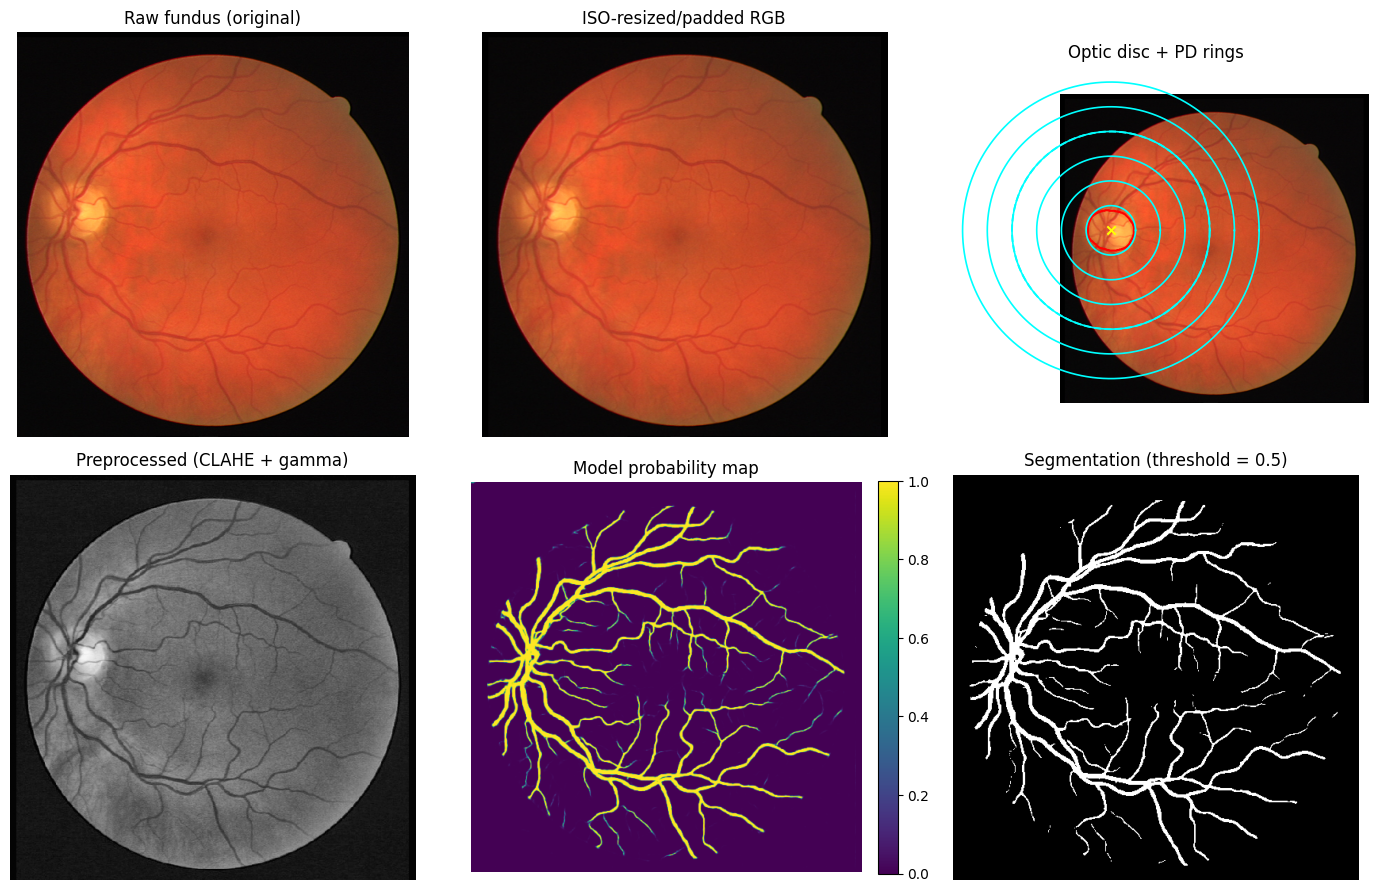

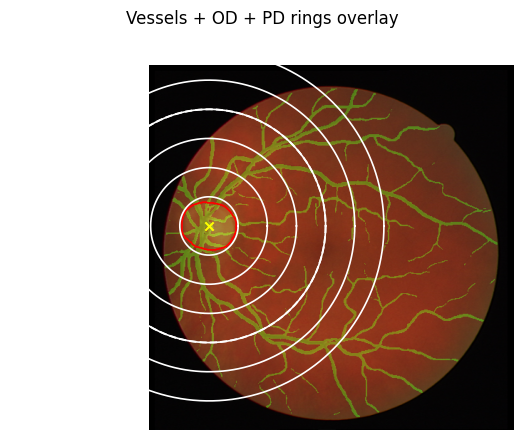

In [8]:
ckpt_path  = "../../outputs/checkpoints/final/[DRIVE] dpcn_refineEdge.pth"
color_path = "../../data/raw/DRIVE/test/images/05_test.png"

out = run_pipeline_with_ckpt(color_path, ckpt_path)

# 2×3 grid
visualize_grid(out)

# Separate overlay (optional)
visualize_overlay(out)


In [9]:
# Full biomarkers (includes PD-normalized and rings if OD was found)
print(json.dumps(out["biomarkers"], indent=2))


{
  "image_shape": [
    512,
    512
  ],
  "global": {
    "area_density": 0.08366012573242188,
    "length_density_px_inv": 0.027522320454863802,
    "fractal_dimension": 1.4825723222111922,
    "tortuosity_mean": 0.1848372519016266,
    "vc_edt": {
      "median_width": 4.0,
      "iqr_width": 2.4721360206604004,
      "frac_thin_len": 0.7148904840787779,
      "frac_med_len": 0.27406589361310507,
      "frac_thick_len": 0.011043622308117063
    },
    "vc_orth": {
      "median_width": 4.5,
      "iqr_width": 3.5,
      "frac_thin_len": 0.4902016878844228,
      "frac_med_len": 0.3351451866685739,
      "frac_thick_len": 0.1746531254470033
    },
    "median_width": 4.5,
    "iqr_width": 3.5,
    "median_width_PD": 0.054931640625,
    "iqr_width_PD": 0.042724609375,
    "length_density_PD_inv": 184.69916603698732
  },
  "topology": {
    "junction_count": 425.0,
    "endpoint_count": 175.0,
    "junction_density": 0.001621246337890625,
    "endpoint_density": 0.000667572021484375,

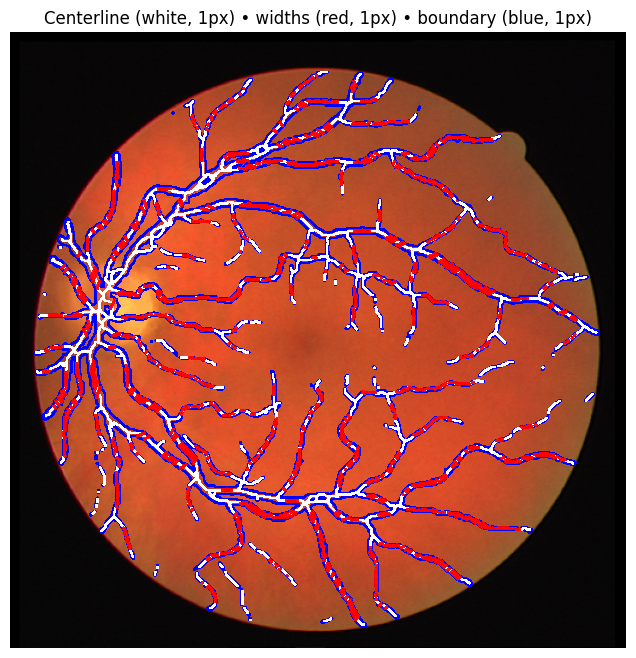

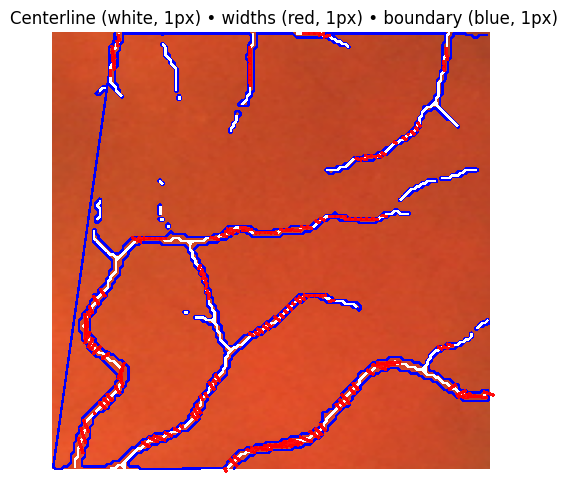

In [10]:
# geometry
skel  = skeletonize_mask(out["pred_mask"])
graph = build_skeleton_graph(skel)
dist  = distance_transform(out["pred_mask"])

# chords 
chords = collect_orthogonal_chords(
    out["pred_mask"], graph, dist,
    stride_by_arc=2.0,       # denser sampling → more chords
    margin_from_nodes=8.0,  # stay farther from bifurcations
    step=0.25,
    max_radius=20.0,
    clip_k_edt=1.25,
    min_len=0.75,
    tan_win_px=11,           # smoother tangent along centerline
    use_pca=True,            # <<< turn PCA on
    pca_radius_px=7,
    kappa_max=0.18,          # skip sharp turns
    asym_max_ratio=1.6
)
plot_vessel_widths_overlay(
    out["rgb_iso"], out["pred_mask"], graph,
    chords=chords,
    chord_lw=1.5, center_lw=1.0, boundary_lw=1.0,
    figsize=(8,8)
)

# zoomed close-up (uses chord center for inclusion)
zoom_center = (int(out["od"]["center_yx"][0] + 80), int(out["od"]["center_yx"][1] + 260))
plot_vessel_widths_overlay(
    out["rgb_iso"], out["pred_mask"], graph,
    chords=chords,
    zoom=(zoom_center[0], zoom_center[1], 80),
    chord_lw=1.5, center_lw=1.0, boundary_lw=1.0,
    figsize=(6,6)
)


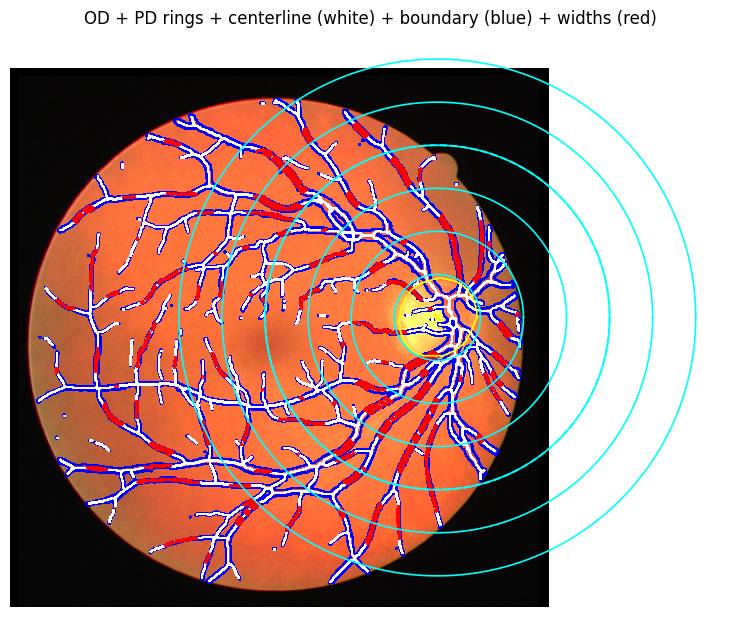

Metric,Value
Area density,0.104088
Length density (px^-1),0.032569
Fractal dimension,1.516004
Tortuosity mean,0.176513
Median width (orth),5.000
IQR width (orth),3.500
Median width / PD,0.061035
IQR width / PD,0.042725
Length density · PD^2,218.565812


Topology,Value
Junctions,575
Endpoints,176
Junction density,0.002193
Endpoint density,0.000671
Angle p10,45.000
Angle p50,121.717
Angle p90,180.000
Gaps (count),1
Gap mean len,1.414
Angles ≤2PD: mean,111.162


Ring,Area dens,Len dens,FracDim,Median W,IQR W,Tortuosity
0.0-0.5PD,0.348347,0.093531,1.006136,9.000,13.250,0.133626
0.5-1.0PD,0.259651,0.068361,1.190323,6.000,3.250,0.185353
1.0-1.5PD,0.148223,0.042753,1.162956,5.000,3.000,0.169422
1.5-2.0PD,0.120453,0.036797,1.103993,5.000,4.000,0.185205
2.0-2.5PD,0.104269,0.034489,1.105845,4.500,3.500,0.186466
2.5-3.0PD,0.096270,0.031923,1.124410,4.500,3.000,0.174015


In [ ]:
# === One-shot run cell: overlay + organized metrics === HEALTHY EYE
# Edit these:
ckpt_path  = "../../outputs/checkpoints/final/[DRIVE] dpcn_refineEdge.pth"
color_path = "../../data/raw/DRIVE/test/images/02_test.png"

import numpy as np, matplotlib.pyplot as plt, pandas as pd
from skimage.measure import find_contours

# 1) Run your pipeline (uses helpers you already defined above)
out = run_pipeline_with_ckpt(color_path, ckpt_path)

# 2) Build geometry for width chords
skel  = skeletonize_mask(out["pred_mask"])
graph = build_skeleton_graph(skel)
dist  = distance_transform(out["pred_mask"])

#— knobs (feel free to tweak)
chords = collect_orthogonal_chords(
    out["pred_mask"], graph, dist,
    stride_by_arc=1.0,        # denser → more chords
    margin_from_nodes=16.0,   # keep away from bifurcations
    step=0.25,
    max_radius=20.0,
    clip_k_edt=1.25,
    min_len=0.75,
    tan_win_px=11,            # smoother tangent along centerline
    use_pca=True,             # robust perpendiculars
    pca_radius_px=7,
    kappa_max=0.18,           # skip sharp turns
    asym_max_ratio=1.6
)

# 3) Single combined overlay (OD + PD rings + centerline + boundary + chords)
rgb_iso    = out["rgb_iso"]
mask       = out["pred_mask"]
disc_mask  = out["disc_mask"]
center_yx  = tuple(out["od"]["center_yx"])
PD_px      = out["od"]["PD_px"]

H, W = mask.shape
fig, ax = plt.subplots(1, 1, figsize=(7.5, 7.5))
ax.imshow(rgb_iso); ax.axis("off")
ax.set_title("OD + PD rings + centerline (white) + boundary (blue) + widths (red)")

# (a) blue boundary (1 px)
for c in find_contours(mask.astype(float), level=0.5):
    yy, xx = c[:, 0], c[:, 1]
    ax.plot(xx, yy, color="blue", lw=1.0, solid_capstyle="butt", antialiased=False)

# (b) white centerline (1 px)
for e in graph["edges"]:
    path = [(graph["nodes"][e["u"]]["y"], graph["nodes"][e["u"]]["x"])] + e["pixels"] + \
           [(graph["nodes"][e["v"]]["y"], graph["nodes"][e["v"]]["x"])]
    yy = np.array([p[0] for p in path]); xx = np.array([p[1] for p in path])
    ax.plot(xx, yy, color="white", lw=1.0, solid_capstyle="butt", antialiased=False)

# (c) red chords (1.5 px)
for (yL, xL), (yR, xR), (yc, xc) in chords:
    ax.plot([xL, xR], [yL, yR], color="red", lw=1.5, alpha=0.95,
            solid_capstyle="butt", antialiased=False)

# (d) OD contour + PD rings
try:
    ax.contour(disc_mask.astype(bool), levels=[0.5], colors='yellow', linewidths=1.2)
except Exception:
    pass

def _draw_pd_rings_inline(ax, center_yx, PD_px, *, max_PD=3.0, step_PD=0.5, color="cyan"):
    if center_yx is None or PD_px is None: return
    cy, cx = center_yx
    theta = np.linspace(0, 2*np.pi, 512)
    ax.scatter([cx], [cy], s=36, marker='x', color='yellow')
    for k in np.arange(step_PD, max_PD + 1e-9, step_PD):
        r = k * PD_px
        xx = cx + r*np.cos(theta); yy = cy + r*np.sin(theta)
        ax.plot(xx, yy, color=color, linewidth=1.2)
    # dashed 2-PD
    r = 2.0 * PD_px
    xx = cx + r*np.cos(theta); yy = cy + r*np.sin(theta)
    ax.plot(xx, yy, color=color, linestyle="--", linewidth=1.4)

_draw_pd_rings_inline(ax, center_yx, PD_px, color="cyan")
plt.tight_layout()
plt.show()

# 4) Organized metrics display (not raw JSON)
bio = out["biomarkers"]

# Global summary
g = bio["global"]
global_rows = [
    ("Area density",                 f"{g['area_density']:.6f}"),
    ("Length density (px^-1)",       f"{g['length_density_px_inv']:.6f}"),
    ("Fractal dimension",            f"{g['fractal_dimension']:.6f}"),
    ("Tortuosity mean",              f"{g['tortuosity_mean']:.6f}"),
    ("Median width (orth)",          f"{g['vc_orth']['median_width']:.3f}"),
    ("IQR width (orth)",             f"{g['vc_orth']['iqr_width']:.3f}"),
]
# PD-normalized if present
if "median_width_PD" in g:
    global_rows += [
        ("Median width / PD",        f"{g['median_width_PD']:.6f}"),
        ("IQR width / PD",           f"{g['iqr_width_PD']:.6f}"),
        ("Length density · PD^2",    f"{g['length_density_PD_inv']:.6f}")
    ]
    
if "tortuosity_mean_PD2_x1e3" in g:
    global_rows += [
        ("Tortuosity (×10⁻³, per PD²)", f"{g['tortuosity_mean_PD2_x1e3']:.3f}")
    ]

df_global = pd.DataFrame(global_rows, columns=["Metric", "Value"])

# Topology summary
t = bio["topology"]
topo_rows = [
    ("Junctions",          int(t.get("junction_count", 0))),
    ("Endpoints",          int(t.get("endpoint_count", 0))),
    ("Junction density",   f"{t.get('junction_density', 0.0):.6f}"),
    ("Endpoint density",   f"{t.get('endpoint_density', 0.0):.6f}"),
    ("Angle p10",          f"{t.get('angle_p10', 0.0):.3f}"),
    ("Angle p50",          f"{t.get('angle_p50', 0.0):.3f}"),
    ("Angle p90",          f"{t.get('angle_p90', 0.0):.3f}"),
    ("Gaps (count)",       int(t.get("gap_count", 0))),
    ("Gap mean len",       f"{t.get('gap_mean_len', 0.0):.3f}"),
]
if isinstance(t.get("angles_2PD"), dict):
    a2 = t["angles_2PD"]
    topo_rows += [
        ("Angles ≤2PD: mean", f"{a2.get('angle_mean', 0.0):.3f}"),
        ("Angles ≤2PD: std",  f"{a2.get('angle_std', 0.0):.3f}")
    ]
df_topo = pd.DataFrame(topo_rows, columns=["Topology", "Value"])

# Ring-wise table (if available)
rings = bio.get("rings") or {}
if rings:
    ring_rows = []
    for ring_name, r in rings.items():
        ring_rows.append([
            ring_name,
            f"{r.get('area_density', 0.0):.6f}",
            f"{r.get('length_density', 0.0):.6f}",
            f"{r.get('fractal_dimension', 0.0):.6f}",
            f"{r.get('median_width', 0.0):.3f}",
            f"{r.get('iqr_width', 0.0):.3f}",
            f"{r.get('tortuosity_mean_PD2_x1e3', 0.0):.3f}",  # <<< new
        ])
    df_rings = pd.DataFrame(ring_rows, columns=[
        "Ring", "Area dens", "Len dens", "FracDim", "Median W", "IQR W", "Tortuosity"
    ])
else:
    df_rings = pd.DataFrame(columns=["Ring","Area dens","Len dens","FracDim","Median W","IQR W","Tortuosity"])

# Pretty print
from IPython.display import display, HTML
display(HTML("<h3>Global Metrics</h3>")); display(df_global.style.hide(axis='index'))
display(HTML("<h3>Topology Metrics</h3>")); display(df_topo.style.hide(axis='index'))
display(HTML("<h3>Ring-wise Metrics</h3>")); display(df_rings.style.hide(axis='index'))


d:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\myenv\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)


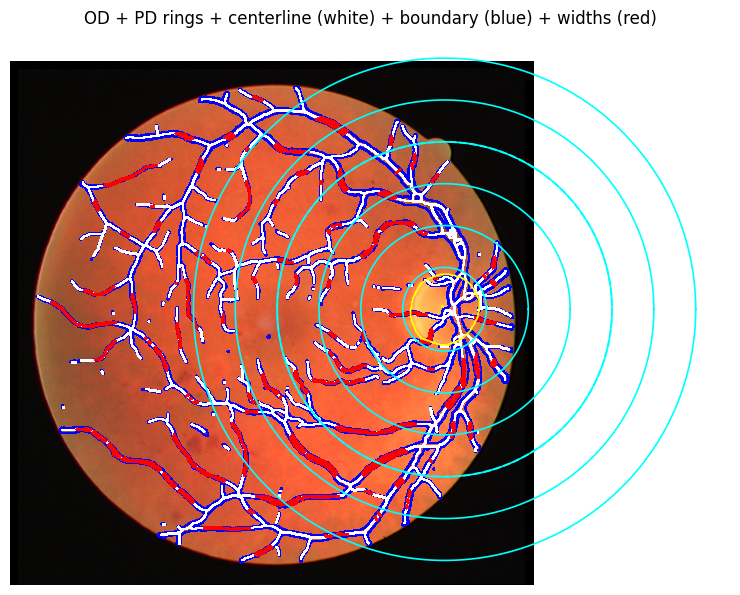

Metric,Value
Area density,0.087002
Length density (px^-1),0.028881
Fractal dimension,1.490009
Tortuosity mean,0.186353
Median width (orth),4.000
IQR width (orth),3.500
Median width / PD,0.048828
IQR width / PD,0.042725
Length density · PD^2,193.815081


Topology,Value
Junctions,475
Endpoints,176
Junction density,0.001812
Endpoint density,0.000671
Angle p10,45.000
Angle p50,123.690
Angle p90,180.000
Gaps (count),2
Gap mean len,1.414
Angles ≤2PD: mean,111.111


Ring,Area dens,Len dens,FracDim,Median W,IQR W,Tortuosity
0.0-0.5PD,0.318915,0.095522,1.017612,8.500,13.500,0.135495
0.5-1.0PD,0.176817,0.054095,1.121667,6.000,5.125,0.171745
1.0-1.5PD,0.123031,0.036687,1.109982,5.000,4.000,0.187387
1.5-2.0PD,0.110711,0.033157,1.110204,5.000,2.500,0.192925
2.0-2.5PD,0.103304,0.034611,1.092277,4.000,3.000,0.195972
2.5-3.0PD,0.063606,0.022573,1.031543,4.000,2.500,0.179233


In [12]:
# === One-shot run cell: overlay + organized metrics ===
# Edit these:
ckpt_path  = "../../outputs/checkpoints/final/[DRIVE] dpcn_refineEdge.pth"
color_path = "../../data/raw/DRIVE/test/images/14_test.png"

import numpy as np, matplotlib.pyplot as plt, pandas as pd
from skimage.measure import find_contours

# 1) Run your pipeline (uses helpers you already defined above)
out = run_pipeline_with_ckpt(color_path, ckpt_path)

# 2) Build geometry for width chords
skel  = skeletonize_mask(out["pred_mask"])
graph = build_skeleton_graph(skel)
dist  = distance_transform(out["pred_mask"])

#— knobs (feel free to tweak)
chords = collect_orthogonal_chords(
    out["pred_mask"], graph, dist,
    stride_by_arc=1.0,        # denser → more chords
    margin_from_nodes=16.0,   # keep away from bifurcations
    step=0.25,
    max_radius=20.0,
    clip_k_edt=1.25,
    min_len=0.75,
    tan_win_px=11,            # smoother tangent along centerline
    use_pca=True,             # robust perpendiculars
    pca_radius_px=7,
    kappa_max=0.18,           # skip sharp turns
    asym_max_ratio=1.6
)

# 3) Single combined overlay (OD + PD rings + centerline + boundary + chords)
rgb_iso    = out["rgb_iso"]
mask       = out["pred_mask"]
disc_mask  = out["disc_mask"]
center_yx  = tuple(out["od"]["center_yx"])
PD_px      = out["od"]["PD_px"]

H, W = mask.shape
fig, ax = plt.subplots(1, 1, figsize=(7.5, 7.5))
ax.imshow(rgb_iso); ax.axis("off")
ax.set_title("OD + PD rings + centerline (white) + boundary (blue) + widths (red)")

# (a) blue boundary (1 px)
for c in find_contours(mask.astype(float), level=0.5):
    yy, xx = c[:, 0], c[:, 1]
    ax.plot(xx, yy, color="blue", lw=1.0, solid_capstyle="butt", antialiased=False)

# (b) white centerline (1 px)
for e in graph["edges"]:
    path = [(graph["nodes"][e["u"]]["y"], graph["nodes"][e["u"]]["x"])] + e["pixels"] + \
           [(graph["nodes"][e["v"]]["y"], graph["nodes"][e["v"]]["x"])]
    yy = np.array([p[0] for p in path]); xx = np.array([p[1] for p in path])
    ax.plot(xx, yy, color="white", lw=1.0, solid_capstyle="butt", antialiased=False)

# (c) red chords (1.5 px)
for (yL, xL), (yR, xR), (yc, xc) in chords:
    ax.plot([xL, xR], [yL, yR], color="red", lw=1.5, alpha=0.95,
            solid_capstyle="butt", antialiased=False)

# (d) OD contour + PD rings
try:
    ax.contour(disc_mask.astype(bool), levels=[0.5], colors='yellow', linewidths=1.2)
except Exception:
    pass

def _draw_pd_rings_inline(ax, center_yx, PD_px, *, max_PD=3.0, step_PD=0.5, color="cyan"):
    if center_yx is None or PD_px is None: return
    cy, cx = center_yx
    theta = np.linspace(0, 2*np.pi, 512)
    ax.scatter([cx], [cy], s=36, marker='x', color='yellow')
    for k in np.arange(step_PD, max_PD + 1e-9, step_PD):
        r = k * PD_px
        xx = cx + r*np.cos(theta); yy = cy + r*np.sin(theta)
        ax.plot(xx, yy, color=color, linewidth=1.2)
    # dashed 2-PD
    r = 2.0 * PD_px
    xx = cx + r*np.cos(theta); yy = cy + r*np.sin(theta)
    ax.plot(xx, yy, color=color, linestyle="--", linewidth=1.4)

_draw_pd_rings_inline(ax, center_yx, PD_px, color="cyan")
plt.tight_layout()
plt.show()

# 4) Organized metrics display (not raw JSON)
bio = out["biomarkers"]

# Global summary
g = bio["global"]
global_rows = [
    ("Area density",                 f"{g['area_density']:.6f}"),
    ("Length density (px^-1)",       f"{g['length_density_px_inv']:.6f}"),
    ("Fractal dimension",            f"{g['fractal_dimension']:.6f}"),
    ("Tortuosity mean",              f"{g['tortuosity_mean']:.6f}"),
    ("Median width (orth)",          f"{g['vc_orth']['median_width']:.3f}"),
    ("IQR width (orth)",             f"{g['vc_orth']['iqr_width']:.3f}"),
]
# PD-normalized if present
if "median_width_PD" in g:
    global_rows += [
        ("Median width / PD",        f"{g['median_width_PD']:.6f}"),
        ("IQR width / PD",           f"{g['iqr_width_PD']:.6f}"),
        ("Length density · PD^2",    f"{g['length_density_PD_inv']:.6f}")
    ]

df_global = pd.DataFrame(global_rows, columns=["Metric", "Value"])

# Topology summary
t = bio["topology"]
topo_rows = [
    ("Junctions",          int(t.get("junction_count", 0))),
    ("Endpoints",          int(t.get("endpoint_count", 0))),
    ("Junction density",   f"{t.get('junction_density', 0.0):.6f}"),
    ("Endpoint density",   f"{t.get('endpoint_density', 0.0):.6f}"),
    ("Angle p10",          f"{t.get('angle_p10', 0.0):.3f}"),
    ("Angle p50",          f"{t.get('angle_p50', 0.0):.3f}"),
    ("Angle p90",          f"{t.get('angle_p90', 0.0):.3f}"),
    ("Gaps (count)",       int(t.get("gap_count", 0))),
    ("Gap mean len",       f"{t.get('gap_mean_len', 0.0):.3f}"),
]
if isinstance(t.get("angles_2PD"), dict):
    a2 = t["angles_2PD"]
    topo_rows += [
        ("Angles ≤2PD: mean", f"{a2.get('angle_mean', 0.0):.3f}"),
        ("Angles ≤2PD: std",  f"{a2.get('angle_std', 0.0):.3f}")
    ]
df_topo = pd.DataFrame(topo_rows, columns=["Topology", "Value"])

# Ring-wise table (if available)
rings = bio.get("rings") or {}
if rings:
    ring_rows = []
    for ring_name, r in rings.items():
        ring_rows.append([
            ring_name,
            f"{r.get('area_density', 0.0):.6f}",
            f"{r.get('length_density', 0.0):.6f}",
            f"{r.get('fractal_dimension', 0.0):.6f}",
            f"{r.get('median_width', 0.0):.3f}",
            f"{r.get('iqr_width', 0.0):.3f}",
            f"{r.get('tortuosity_mean', 0.0):.6f}",
        ])
    df_rings = pd.DataFrame(ring_rows, columns=[
        "Ring", "Area dens", "Len dens", "FracDim", "Median W", "IQR W", "Tortuosity"
    ])
else:
    df_rings = pd.DataFrame(columns=["Ring","Area dens","Len dens","FracDim","Median W","IQR W","Tortuosity"])

# Pretty print
from IPython.display import display, HTML
display(HTML("<h3>Global Metrics</h3>")); display(df_global.style.hide(axis='index'))
display(HTML("<h3>Topology Metrics</h3>")); display(df_topo.style.hide(axis='index'))
display(HTML("<h3>Ring-wise Metrics</h3>")); display(df_rings.style.hide(axis='index'))

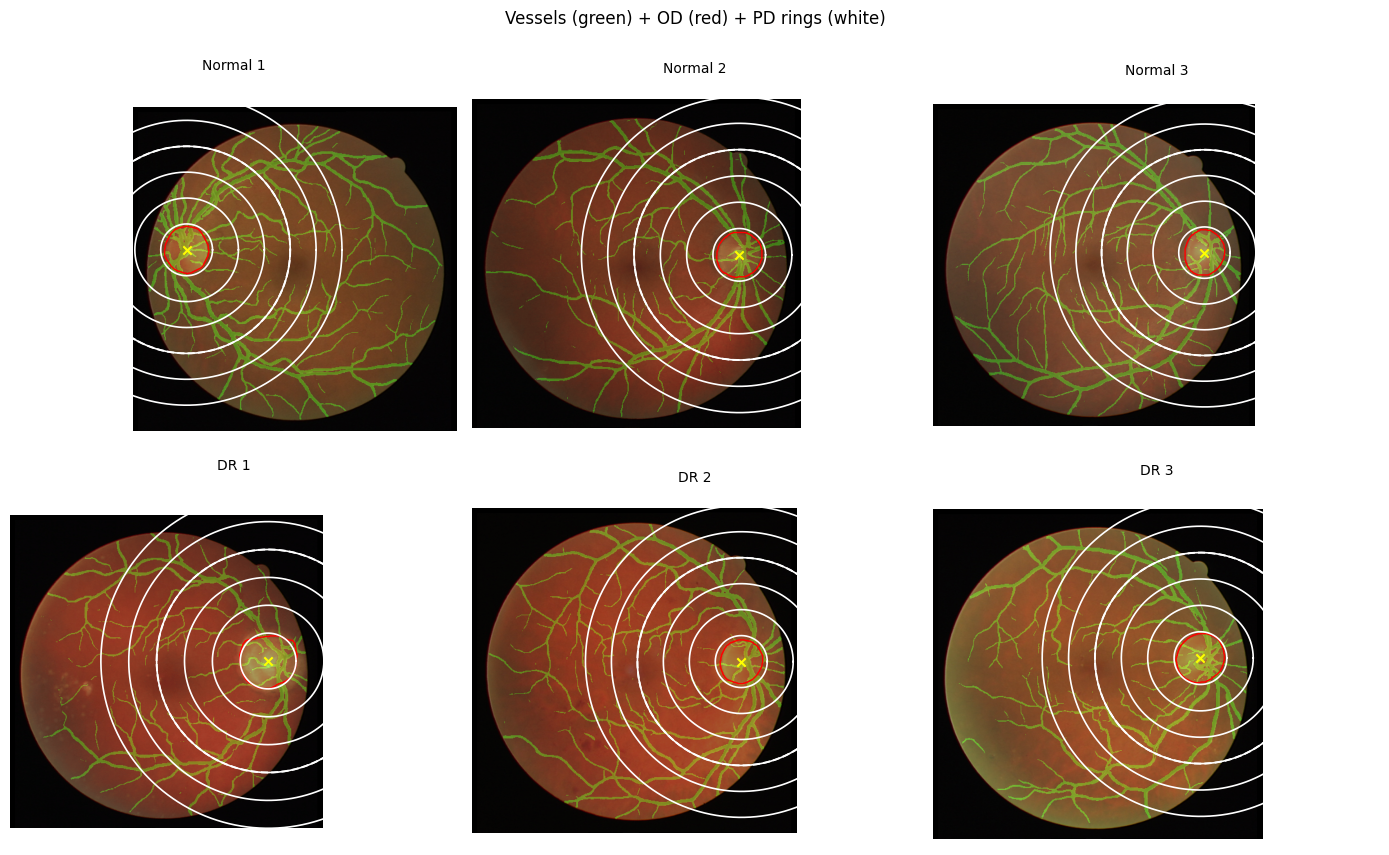

,Normal_mean,Normal_sd,DR_mean,DR_sd,Δ (DR-Norm),%Δ vs Norm
area_density,0.0915,0.0110,0.0814,0.0058,-0.0101,-11.0342
length_density_PD_inv,200.1950,25.2502,193.5898,15.5997,-6.6052,-3.2994
median_width_PD,0.0549,0.0000,0.0492,0.0056,-0.0057,-10.4457
iqr_width_PD,0.0427,0.0000,0.0413,0.0025,-0.0015,-3.4181
tortuosity_mean,0.1844,0.0018,0.1863,0.0021,0.0019,1.0312
junction_density,0.0018,0.0004,0.0016,0.0002,-0.0002,-11.3182
endpoint_density,0.0008,0.0001,0.0006,0.0000,-0.0001,-15.0250
angle_mean_2PD,111.4871,0.9343,111.3068,0.4366,-0.1804,-0.1618


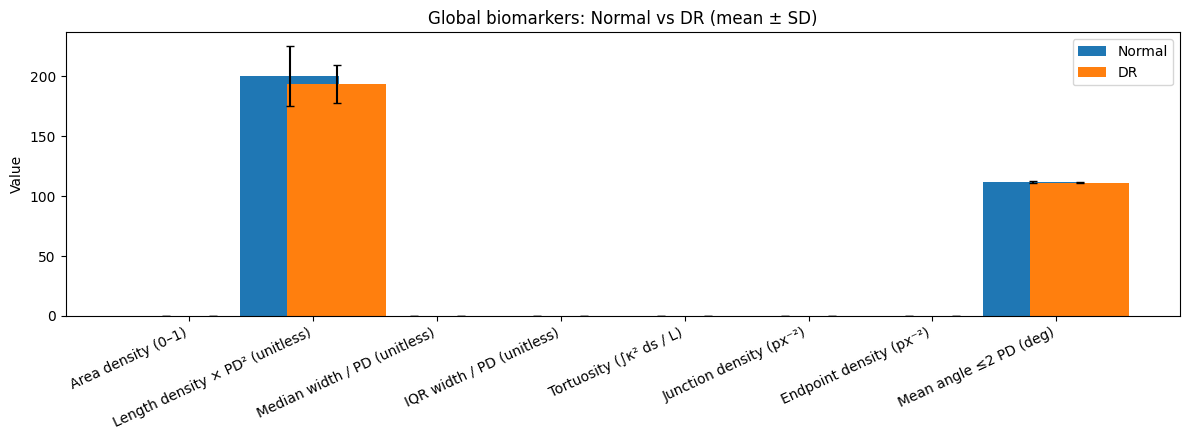

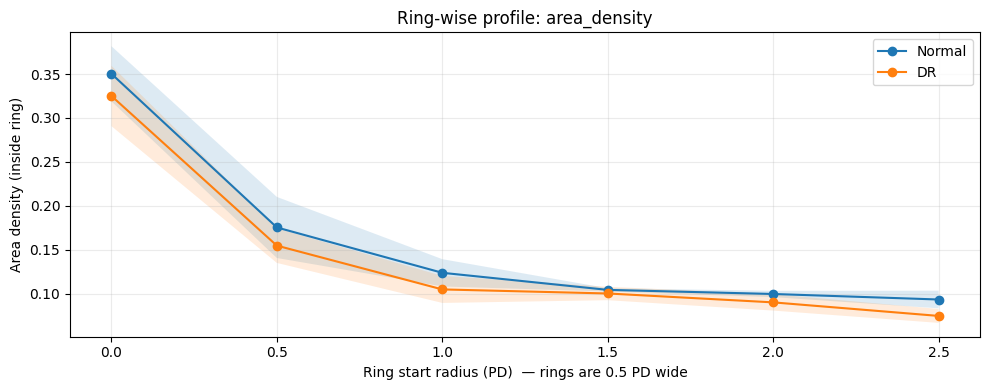

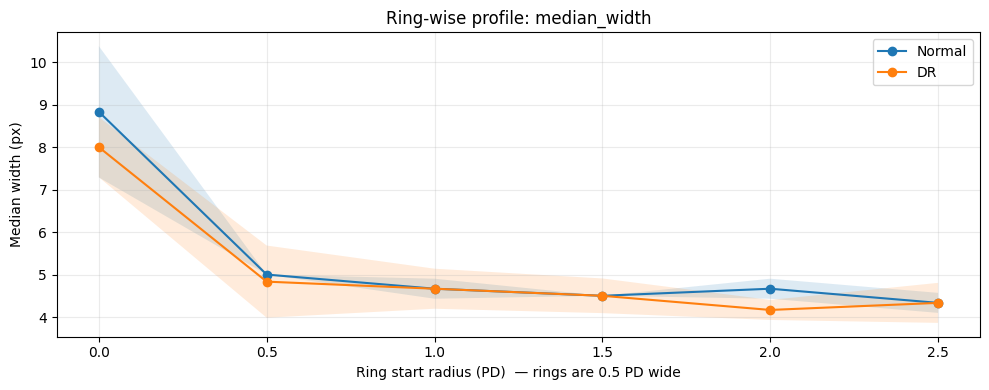

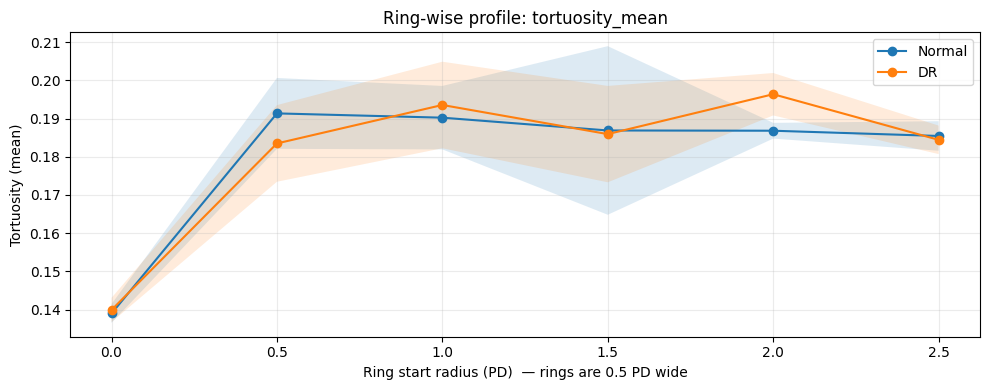


Top deltas (DR - Normal):
                       Δ (DR-Norm)  %Δ vs Norm
tortuosity_mean               0.00        1.03
angle_mean_2PD               -0.18       -0.16
length_density_PD_inv        -6.61       -3.30
iqr_width_PD                 -0.00       -3.42
median_width_PD              -0.01      -10.45
area_density                 -0.01      -11.03
junction_density             -0.00      -11.32
endpoint_density             -0.00      -15.03


In [13]:
# ==== GROUP COMPARISON: Normal vs DR (overlays + aggregated metrics/plots) ====
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# --------- USER INPUTS ----------
ckpt_path = "../../outputs/checkpoints/final/[DRIVE] dpcn_refineEdge.pth"

normal_paths = [
    "../../data/raw/DRIVE/test/images/01_test.png",
    "../../data/raw/DRIVE/test/images/10_test.png",
    "../../data/raw/DRIVE/test/images/13_test.png",
]
dr_paths = [
    "../../data/raw/DRIVE/test/images/08_test.png",
    "../../data/raw/DRIVE/test/images/14_test.png",
    "../../data/raw/DRIVE/test/images/17_test.png",
]

# --------- HELPERS (use your previously-defined pipeline pieces) ----------
def run_list(paths):
    outs = []
    for p in paths:
        try:
            o = run_pipeline_with_ckpt(p, ckpt_path)
            outs.append(o)
        except Exception as e:
            print(f"[warn] failed on {p}: {e}")
    return outs

def draw_overlay_ax(ax, out, title=None, alpha=0.35):
    rgb_iso    = out["rgb_iso"]
    disc_mask  = out["disc_mask"]
    center_yx  = tuple(out["od"]["center_yx"])
    PD_px      = out["od"]["PD_px"]
    mask_thr05 = out["pred_mask_thr05"]

    overlay = np.zeros_like(rgb_iso, dtype=np.uint8)
    overlay[..., 1] = (mask_thr05.astype(np.uint8) * 255)  # green vessels

    ax.imshow(rgb_iso); ax.imshow(overlay, alpha=alpha); ax.axis("off")
    try:
        ax.contour(disc_mask.astype(bool), levels=[0.5], colors='r', linewidths=1.0)
    except Exception:
        pass
    _draw_pd_rings(ax, center_yx, PD_px, ring_color='white')
    if title: ax.set_title(title, fontsize=10)

def flatten_metrics(out):
    """Return flat dict of globals + selected topology + ring profiles."""
    bio = out["biomarkers"]; g = bio["global"]; t = bio["topology"]
    row = {
        "area_density": g["area_density"],
        "length_density_PD_inv": g.get("length_density_PD_inv", np.nan),
        "median_width_PD": g.get("median_width_PD", np.nan),
        "iqr_width_PD": g.get("iqr_width_PD", np.nan),
        "tortuosity_mean": g["tortuosity_mean"],
        "junction_density": t.get("junction_density", np.nan),
        "endpoint_density": t.get("endpoint_density", np.nan),
        "angle_mean_2PD": (t.get("angles_2PD") or {}).get("angle_mean", np.nan),
    }
    # ring metrics (keep stable order)
    rings = bio.get("rings") or {}
    ordered = []
    for k in rings.keys():
        try:
            start = float(k.split("-")[0])
            ordered.append((start, k))
        except:
            continue
    ordered = [k for _, k in sorted(ordered)]
    for k in ordered:
        r = rings[k]
        row[f"{k}|area_density"]   = r.get("area_density",   np.nan)
        row[f"{k}|median_width"]   = r.get("median_width",   np.nan)
        row[f"{k}|tortuosity_mean"] = r.get("tortuosity_mean", np.nan)
    return row

def agg_compare(df_norm, df_dr, metrics):
    nm, dm = df_norm[metrics].mean(), df_dr[metrics].mean()
    ns, ds = df_norm[metrics].std(),  df_dr[metrics].std()
    comp = pd.concat([nm.rename("Normal_mean"),
                      ns.rename("Normal_sd"),
                      dm.rename("DR_mean"),
                      ds.rename("DR_sd")], axis=1)
    comp["Δ (DR-Norm)"] = comp["DR_mean"] - comp["Normal_mean"]
    comp["%Δ vs Norm"]  = 100.0 * comp["Δ (DR-Norm)"] / np.where(comp["Normal_mean"]!=0, comp["Normal_mean"], np.nan)
    return comp

# --------- RUN PIPELINE ----------
outs_norm = run_list(normal_paths)
outs_dr   = run_list(dr_paths)

# --------- OVERLAYS (2×3 grid) ----------
fig, axs = plt.subplots(2, 3, figsize=(14, 9))
for i in range(3):
    draw_overlay_ax(axs[0, i], outs_norm[i], f"Normal {i+1}") if i < len(outs_norm) else axs[0, i].axis("off")
    draw_overlay_ax(axs[1, i], outs_dr[i],   f"DR {i+1}")     if i < len(outs_dr)   else axs[1, i].axis("off")
fig.suptitle("Vessels (green) + OD (red) + PD rings (white)", y=0.98)
plt.tight_layout(); plt.show()

# --------- TABULATE METRICS ----------
rows_norm = [flatten_metrics(o) for o in outs_norm]
rows_dr   = [flatten_metrics(o) for o in outs_dr]
dfN, dfD  = pd.DataFrame(rows_norm), pd.DataFrame(rows_dr)

# choose key globals for comparison
key_glob = [
    "area_density", "length_density_PD_inv",
    "median_width_PD", "iqr_width_PD",
    "tortuosity_mean", "junction_density", "endpoint_density", "angle_mean_2PD"
]
comp_glob = agg_compare(dfN, dfD, key_glob)
display(comp_glob.round(4))

# --------- BAR CHARTS (means ± SD) ----------
def bar_compare(dfN, dfD, metrics, title, label_map=None):
    meansN, sdsN = dfN[metrics].mean(), dfN[metrics].std()
    meansD, sdsD = dfD[metrics].mean(), dfD[metrics].std()
    ind = np.arange(len(metrics)); w = 0.38
    plt.figure(figsize=(12, 4.5))
    plt.bar(ind - w/2, meansN.values, yerr=sdsN.values, capsize=3, label="Normal")
    plt.bar(ind + w/2, meansD.values, yerr=sdsD.values, capsize=3, label="DR")
    # use pretty x-tick labels with units
    tick_labels = [label_map.get(m, m) if label_map else m for m in metrics]
    plt.xticks(ind, tick_labels, rotation=25, ha="right")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()



label_map = {
    "area_density": "Area density (0–1)",
    "length_density_PD_inv": "Length density × PD² (unitless)",
    "median_width_PD": "Median width / PD (unitless)",
    "iqr_width_PD": "IQR width / PD (unitless)",
    "tortuosity_mean": "Tortuosity (∫κ² ds / L)",
    "junction_density": "Junction density (px⁻²)",
    "endpoint_density": "Endpoint density (px⁻²)",
    "angle_mean_2PD": "Mean angle ≤2 PD (deg)",
}

bar_compare(dfN, dfD, key_glob, "Global biomarkers: Normal vs DR (mean ± SD)", label_map)


# --------- RING-WISE RADIAL PROFILES ----------
# pick ring columns by prefix
def ring_profile(df, metric_suffix):
    cols = [c for c in df.columns if c.endswith("|"+metric_suffix)]
    # sort by ring start value
    keyed = []
    for c in cols:
        try:
            start = float(c.split("|")[0].split("-")[0])
            keyed.append((start, c))
        except:
            pass
    cols = [c for _, c in sorted(keyed)]
    arr = df[cols].to_numpy(dtype=float)
    # x positions from column names
    xs = [float(c.split("|")[0].split("-")[0]) for c in cols]  # 0.0, 0.5, 1.0, ...
    return np.array(xs), arr

for metric, ylabel in [
    ("area_density",   "Area density (inside ring)"),
    ("median_width",   "Median width (px)"),
    ("tortuosity_mean","Tortuosity (mean)"),
]:
    xsN, A_N = ring_profile(dfN, metric)
    xsD, A_D = ring_profile(dfD, metric)
    xs = xsN if len(xsN)>=len(xsD) else xsD

    meanN, sdN = (A_N.mean(0), A_N.std(0)) if A_N.size else (np.array([]), np.array([]))
    meanD, sdD = (A_D.mean(0), A_D.std(0)) if A_D.size else (np.array([]), np.array([]))

    plt.figure(figsize=(10, 4))
    if meanN.size:
        plt.plot(xs, meanN, marker="o", label="Normal")
        plt.fill_between(xs, meanN-sdN, meanN+sdN, alpha=0.15)
    if meanD.size:
        plt.plot(xs, meanD, marker="o", label="DR")
        plt.fill_between(xs, meanD-sdD, meanD+sdD, alpha=0.15)
    plt.xlabel("Ring start radius (PD)  — rings are 0.5 PD wide")
    plt.ylabel(ylabel); plt.title(f"Ring-wise profile: {metric}")
    plt.grid(alpha=0.25); plt.legend(); plt.tight_layout(); plt.show()

# --------- OPTIONAL: quick textual summary ----------
delta = comp_glob[["Δ (DR-Norm)", "%Δ vs Norm"]].round(2)
print("\nTop deltas (DR - Normal):")
print(delta.sort_values(by="%Δ vs Norm", ascending=False))


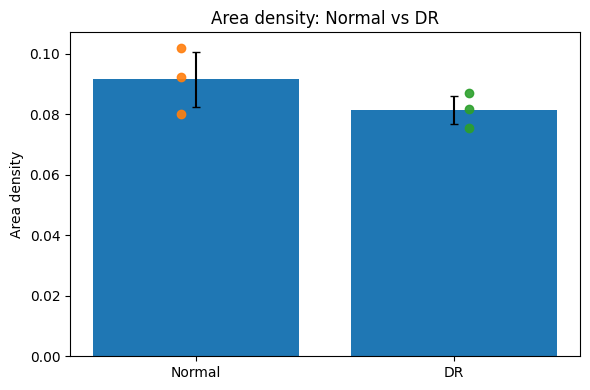

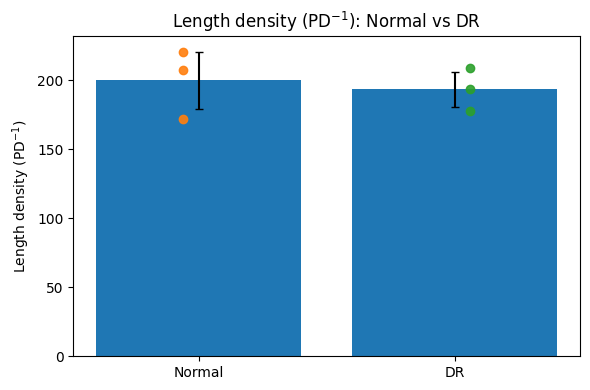

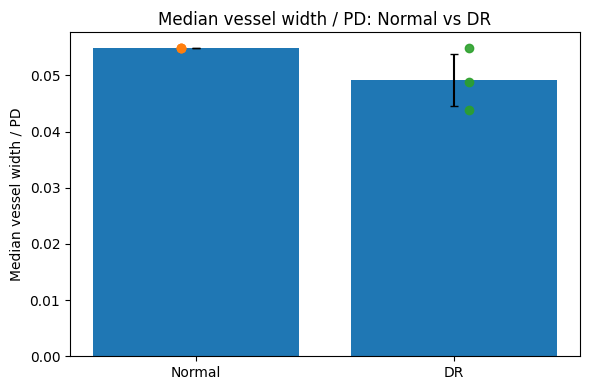

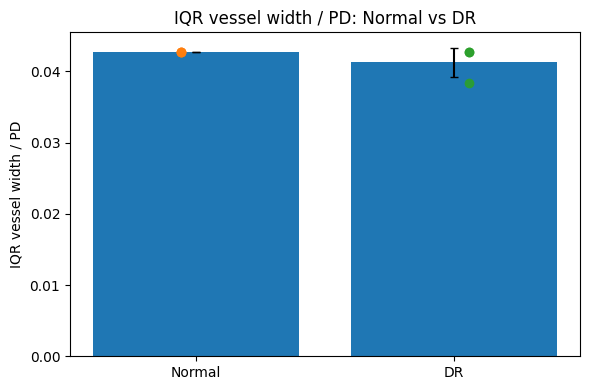

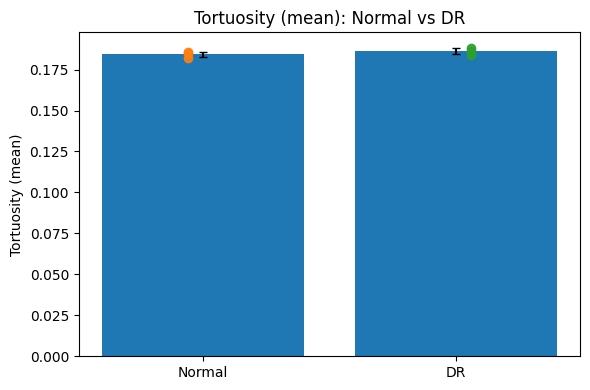

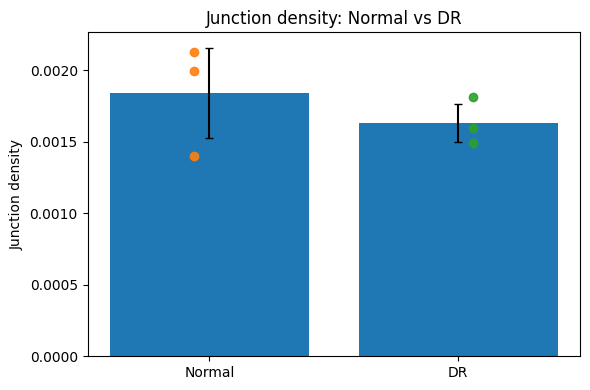

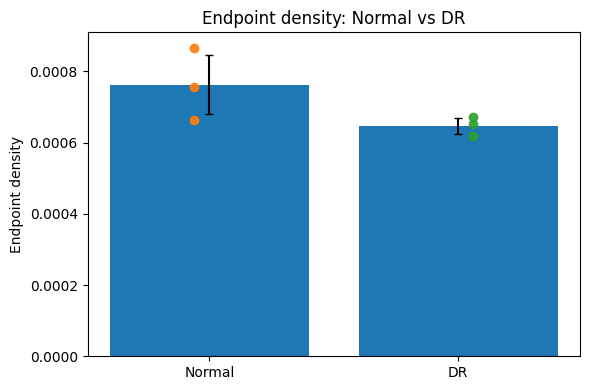

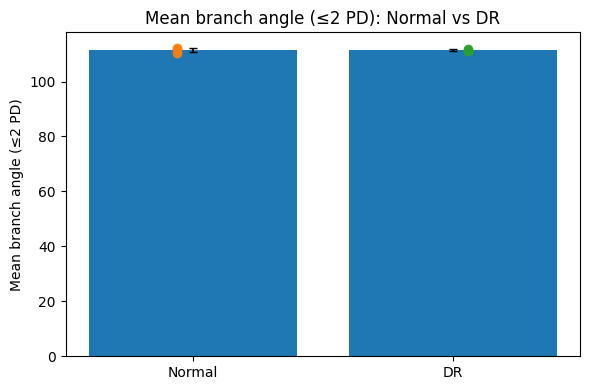

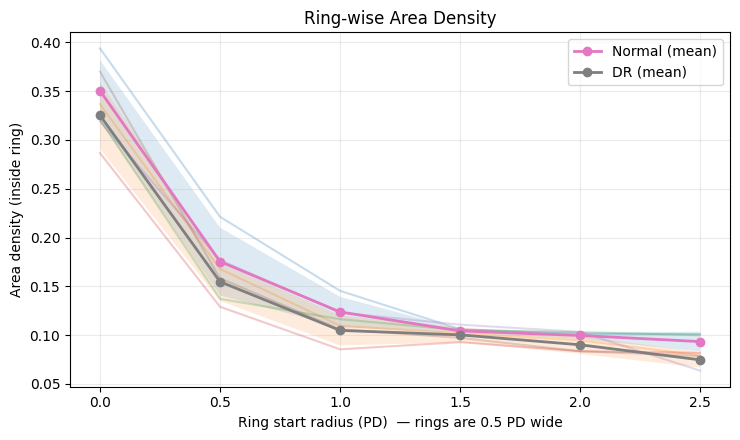

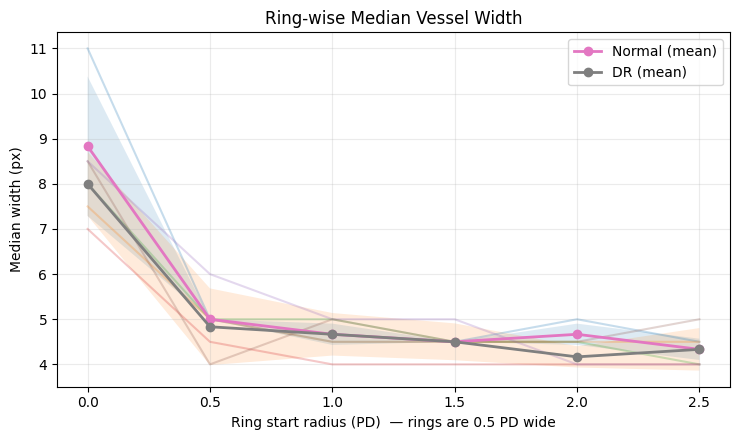

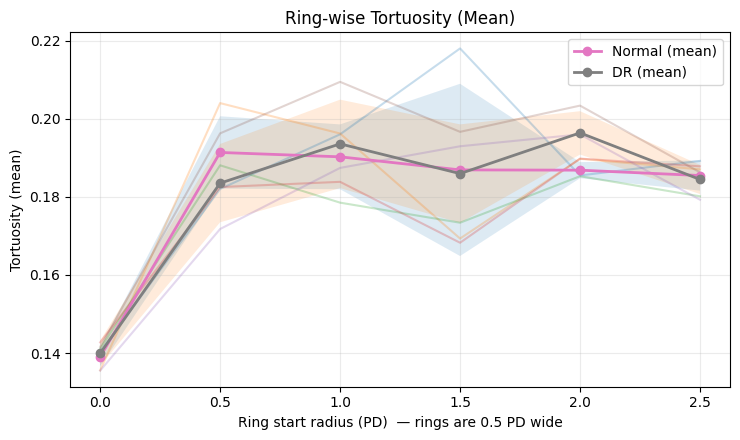

In [14]:
# === INDIVIDUAL PLOTS PER QUANTITATIVE VALUE (Normal vs DR) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# If you ran the previous cell, dfN/dfD exist. If not, raise a friendly error.
for _name in ["dfN", "dfD"]:
    if _name not in globals():
        raise RuntimeError(f"{_name} is missing. Run the group-comparison cell first to build dfN/dfD.")

# ---- 1) Globals: one plot per metric (bar + per-image dots) ----
metrics_map = {
    "area_density": "Area density",
    "length_density_PD_inv": "Length density (PD$^{-1}$)",
    "median_width_PD": "Median vessel width / PD",
    "iqr_width_PD": "IQR vessel width / PD",
    "tortuosity_mean": "Tortuosity (mean)",
    "junction_density": "Junction density",
    "endpoint_density": "Endpoint density",
    "angle_mean_2PD": "Mean branch angle (≤2 PD)"
}

def _bar_with_points(norm_vals, dr_vals, title, ylabel):
    # Bar means ± SD
    means = [np.nanmean(norm_vals), np.nanmean(dr_vals)]
    sds   = [np.nanstd(norm_vals),  np.nanstd(dr_vals)]
    x = np.array([0, 1])
    plt.figure(figsize=(6, 4))
    plt.bar(x, means, yerr=sds, capsize=3)
    # per-image points
    jitter = 0.06
    plt.scatter(np.zeros_like(norm_vals) + (0 - jitter), norm_vals, marker="o", alpha=0.9)
    plt.scatter(np.zeros_like(dr_vals)   + (1 + jitter),  dr_vals,   marker="o", alpha=0.9)
    plt.xticks([0, 1], ["Normal", "DR"])
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

for key, label in metrics_map.items():
    nvals = dfN[key].astype(float).to_numpy()
    dvals = dfD[key].astype(float).to_numpy()
    _bar_with_points(nvals, dvals, f"{label}: Normal vs DR", label)

# ---- 2) Ring-wise: one plot per ring metric (per-image lines + mean±SD) ----
def _ring_profile(df: pd.DataFrame, metric_suffix: str):
    """Returns xs (ring start PD) and values matrix [num_images x num_rings]."""
    cols = [c for c in df.columns if c.endswith("|"+metric_suffix)]
    keyed = []
    for c in cols:
        try:
            start = float(c.split("|")[0].split("-")[0])  # "0.5-1.0PD|area_density" -> 0.5
            keyed.append((start, c))
        except:
            pass
    cols = [c for _, c in sorted(keyed)]
    if not cols:
        return np.array([]), np.empty((0, 0))
    xs = np.array([float(c.split("|")[0].split("-")[0]) for c in cols], dtype=float)
    vals = df[cols].astype(float).to_numpy()
    return xs, vals

def _plot_ring_metric(metric_suffix: str, title: str, ylabel: str):
    xsN, A_N = _ring_profile(dfN, metric_suffix)
    xsD, A_D = _ring_profile(dfD, metric_suffix)

    if A_N.size == 0 and A_D.size == 0:
        print(f"[skip] No ring data for '{metric_suffix}'.")
        return

    # Use the longer x grid if they differ
    xs = xsN if xsN.size >= xsD.size else xsD

    plt.figure(figsize=(7.5, 4.5))

    # Per-image lines (faint)
    if A_N.size:
        for i in range(A_N.shape[0]):
            plt.plot(xsN, A_N[i], alpha=0.25)
    if A_D.size:
        for i in range(A_D.shape[0]):
            plt.plot(xsD, A_D[i], alpha=0.25)

    # Means ± SD
    if A_N.size:
        meanN, sdN = A_N.mean(0), A_N.std(0)
        plt.plot(xsN, meanN, marker="o", linewidth=2, label="Normal (mean)")
        plt.fill_between(xsN, meanN - sdN, meanN + sdN, alpha=0.15)
    if A_D.size:
        meanD, sdD = A_D.mean(0), A_D.std(0)
        plt.plot(xsD, meanD, marker="o", linewidth=2, label="DR (mean)")
        plt.fill_between(xsD, meanD - sdD, meanD + sdD, alpha=0.15)

    plt.xlabel("Ring start radius (PD)  — rings are 0.5 PD wide")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Choose which ring metrics to display individually
_ring_metrics = [
    ("area_density",    "Ring-wise Area Density",          "Area density (inside ring)"),
    ("median_width",    "Ring-wise Median Vessel Width",   "Median width (px)"),
    ("tortuosity_mean", "Ring-wise Tortuosity (Mean)",     "Tortuosity (mean)"),
]
for suffix, title, ylabel in _ring_metrics:
    _plot_ring_metric(suffix, title, ylabel)
